# 📊 Analisis Komparatif: Naive Bayes vs LSTM vs Transformer
### Intent Classification pada Customer Support Chatbot

**Dataset:** Bitext Customer Support (20K+ utterances, 27 intents)

**Tujuan Penelitian:**
1. Membandingkan performa 3 paradigma ML: Classical ML, Deep Learning, dan State-of-the-art
2. Menganalisis trade-off accuracy vs efficiency
3. Evaluasi robustness terhadap linguistic phenomena (noise, typos, colloquial)

---

## 🔧 1. Setup & Installation

Install semua library yang dibutuhkan untuk ketiga model.

In [ ]:
# Install required libraries
!pip install -q kaggle transformers datasets accelerate scikit-learn nltk wordcloud
!pip install -q tensorflow

import warnings
warnings.filterwarnings('ignore')

print("✅ Installation complete!")

✅ Installation complete!


## 📥 2. Import Libraries

Import semua library yang diperlukan untuk data processing, modeling, dan visualization.

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np
import json
import time
from collections import Counter

# Text processing
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Sklearn for Naive Bayes
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# TensorFlow/Keras for LSTM
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Transformers for BERT
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from datasets import Dataset

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Google Colab utilities
from google.colab import files
import os

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 🔑 3. Upload Kaggle API Key

**Instruksi:**
1. Download `kaggle.json` dari akun Kaggle Anda (Account → API → Create New API Token)
2. Upload file saat diminta
3. Script akan otomatis setup credentials

In [ ]:
# Upload kaggle.json
print("📤 Silakan upload file kaggle.json Anda...")
uploaded = files.upload()

# Setup Kaggle credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("\n✅ Kaggle API configured successfully!")

📤 Silakan upload file kaggle.json Anda...


Saving kaggle.json to kaggle.json

✅ Kaggle API configured successfully!


## 📦 4. Download Dataset

Download dataset Bitext dari Kaggle secara otomatis.

In [ ]:
# Download dataset
!kaggle datasets download -d bitext/training-dataset-for-chatbotsvirtual-assistants

# Unzip dataset
!unzip -q training-dataset-for-chatbotsvirtual-assistants.zip -d bitext_data

print("✅ Dataset downloaded and extracted!")

# List files
!ls -lh bitext_data/

Dataset URL: https://www.kaggle.com/datasets/bitext/training-dataset-for-chatbotsvirtual-assistants
License(s): copyright-authors
  0% 0.00/1.16M [00:00<?, ?B/s]
100% 1.16M/1.16M [00:00<00:00, 682MB/s]
✅ Dataset downloaded and extracted!
total 8.0K
drwxr-xr-x 3 root root 4.0K Feb 15 13:34 20000-Utterances-Training-dataset-for-chatbots-virtual-assistant-Bitext-sample
drwxr-xr-x 3 root root 4.0K Feb 15 13:34 Bitext_Sample_Customer_Service_Training_Dataset


## 📊 5. Load & Explore Data

Load dataset dan lakukan exploratory data analysis untuk memahami karakteristik data.

In [ ]:
# Load dataset
df = pd.read_csv('bitext_data/20000-Utterances-Training-dataset-for-chatbots-virtual-assistant-Bitext-sample/20000-Utterances-Training-dataset-for-chatbots-virtual-assistant-Bitext-sample/20000-Utterances-Training-dataset-for-chatbots-virtual-assistant-Bitext-sample.csv')

# Display basic info
print("📋 Dataset Shape:", df.shape)
print("\n🔍 Column Names:")
print(df.columns.tolist())
print("\n📝 First 5 rows:")
display(df.head())

📋 Dataset Shape: (21534, 4)

🔍 Column Names:
['flags', 'utterance', 'category', 'intent']

📝 First 5 rows:


,flags,utterance,category,intent
0,BILC,"I don't have an online account, what do I have...",ACCOUNT,create_account
1,BILQZ,can you tell me if i can regisger two accounts...,ACCOUNT,create_account
2,BPLC,"I have no online account, open one, please",ACCOUNT,create_account
3,BIPLD,"could you ask an agent how to open an account,...",ACCOUNT,create_account
4,BLQC,"i want an online account, create one",ACCOUNT,create_account


In [ ]:
# Data Info
print("ℹ️ Dataset Information:")
print("="*60)
df.info()

print("\n📈 Missing Values:")
print(df.isnull().sum())

print("\n🎯 Number of Unique Intents:", df['intent'].nunique())
print("🏷️ Number of Unique Categories:", df['category'].nunique())

ℹ️ Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21534 entries, 0 to 21533
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   flags      21534 non-null  object
 1   utterance  21534 non-null  object
 2   category   21534 non-null  object
 3   intent     21534 non-null  object
dtypes: object(4)
memory usage: 673.1+ KB

📈 Missing Values:
flags        0
utterance    0
category     0
intent       0
dtype: int64

🎯 Number of Unique Intents: 27
🏷️ Number of Unique Categories: 11


## 📈 6. Data Visualization & Analysis

Visualisasi distribusi intent, category, dan linguistic flags untuk memahami karakteristik dataset.

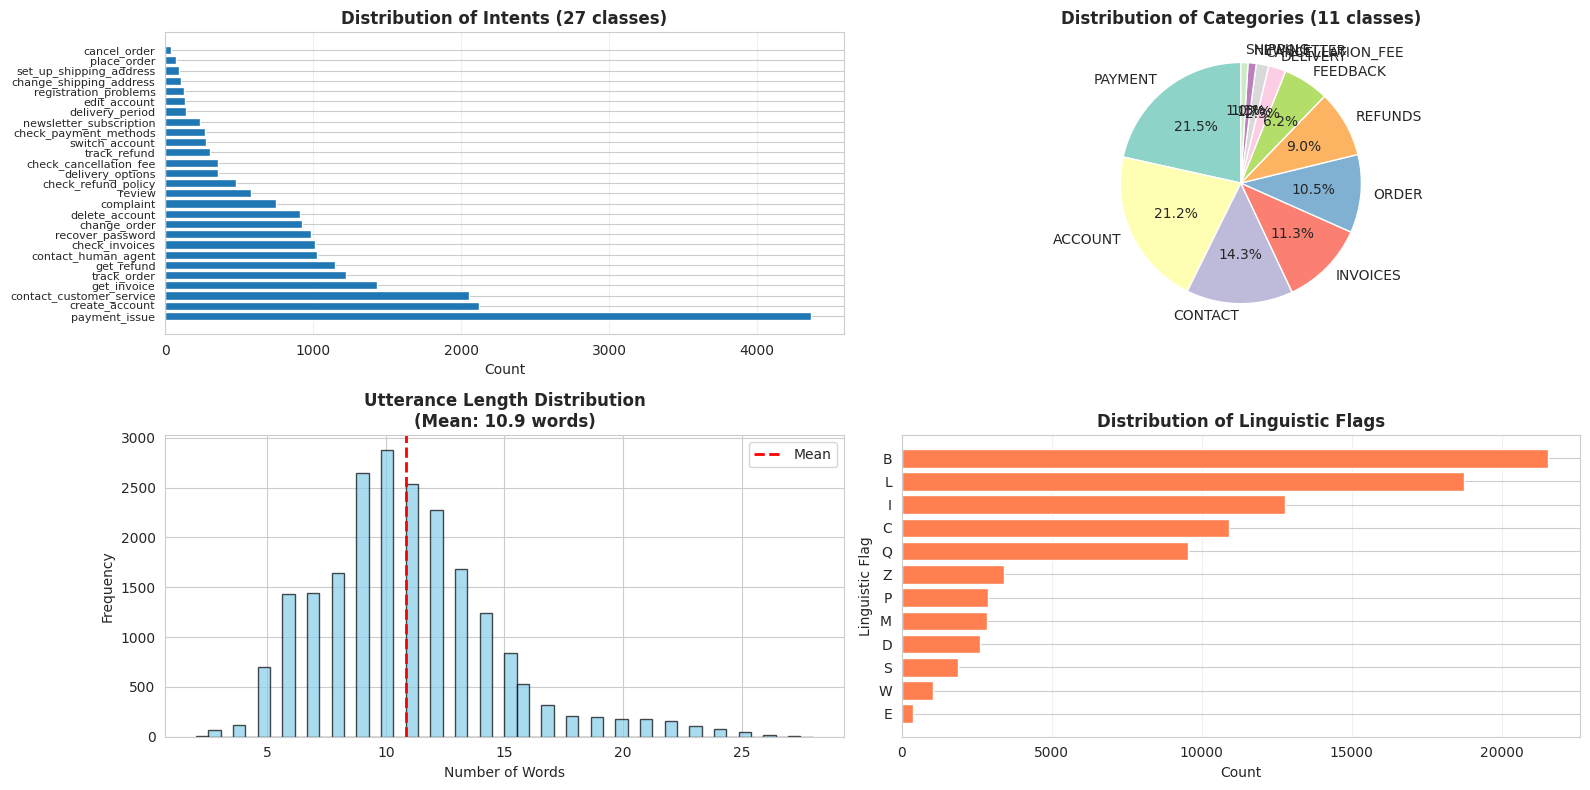


📊 Dataset Statistics:
Total Utterances: 21,534
Number of Intents: 27
Number of Categories: 11
Average Utterance Length: 10.86 words
Min Utterance Length: 2 words
Max Utterance Length: 28 words


In [ ]:
# Intent distribution
plt.figure(figsize=(16, 8))

# Plot 1: Intent distribution
plt.subplot(2, 2, 1)
intent_counts = df['intent'].value_counts()
plt.barh(range(len(intent_counts)), intent_counts.values)
plt.yticks(range(len(intent_counts)), intent_counts.index, fontsize=8)
plt.xlabel('Count', fontsize=10)
plt.title('Distribution of Intents (27 classes)', fontsize=12, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Plot 2: Category distribution
plt.subplot(2, 2, 2)
category_counts = df['category'].value_counts()
colors = plt.cm.Set3(range(len(category_counts)))
plt.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Distribution of Categories (11 classes)', fontsize=12, fontweight='bold')

# Plot 3: Utterance length distribution
plt.subplot(2, 2, 3)
df['utterance_length'] = df['utterance'].str.split().str.len()
plt.hist(df['utterance_length'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Number of Words', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.title(f'Utterance Length Distribution\n(Mean: {df["utterance_length"].mean():.1f} words)',
          fontsize=12, fontweight='bold')
plt.axvline(df['utterance_length'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
plt.legend()

# Plot 4: Linguistic flags distribution
plt.subplot(2, 2, 4)
flag_counts = Counter()
for flags in df['flags'].dropna():
    flag_counts.update(list(flags))
flags_df = pd.DataFrame.from_dict(flag_counts, orient='index', columns=['count']).sort_values('count', ascending=True)
plt.barh(flags_df.index, flags_df['count'], color='coral')
plt.xlabel('Count', fontsize=10)
plt.ylabel('Linguistic Flag', fontsize=10)
plt.title('Distribution of Linguistic Flags', fontsize=12, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("\n📊 Dataset Statistics:")
print("="*60)
print(f"Total Utterances: {len(df):,}")
print(f"Number of Intents: {df['intent'].nunique()}")
print(f"Number of Categories: {df['category'].nunique()}")
print(f"Average Utterance Length: {df['utterance_length'].mean():.2f} words")
print(f"Min Utterance Length: {df['utterance_length'].min()} words")
print(f"Max Utterance Length: {df['utterance_length'].max()} words")

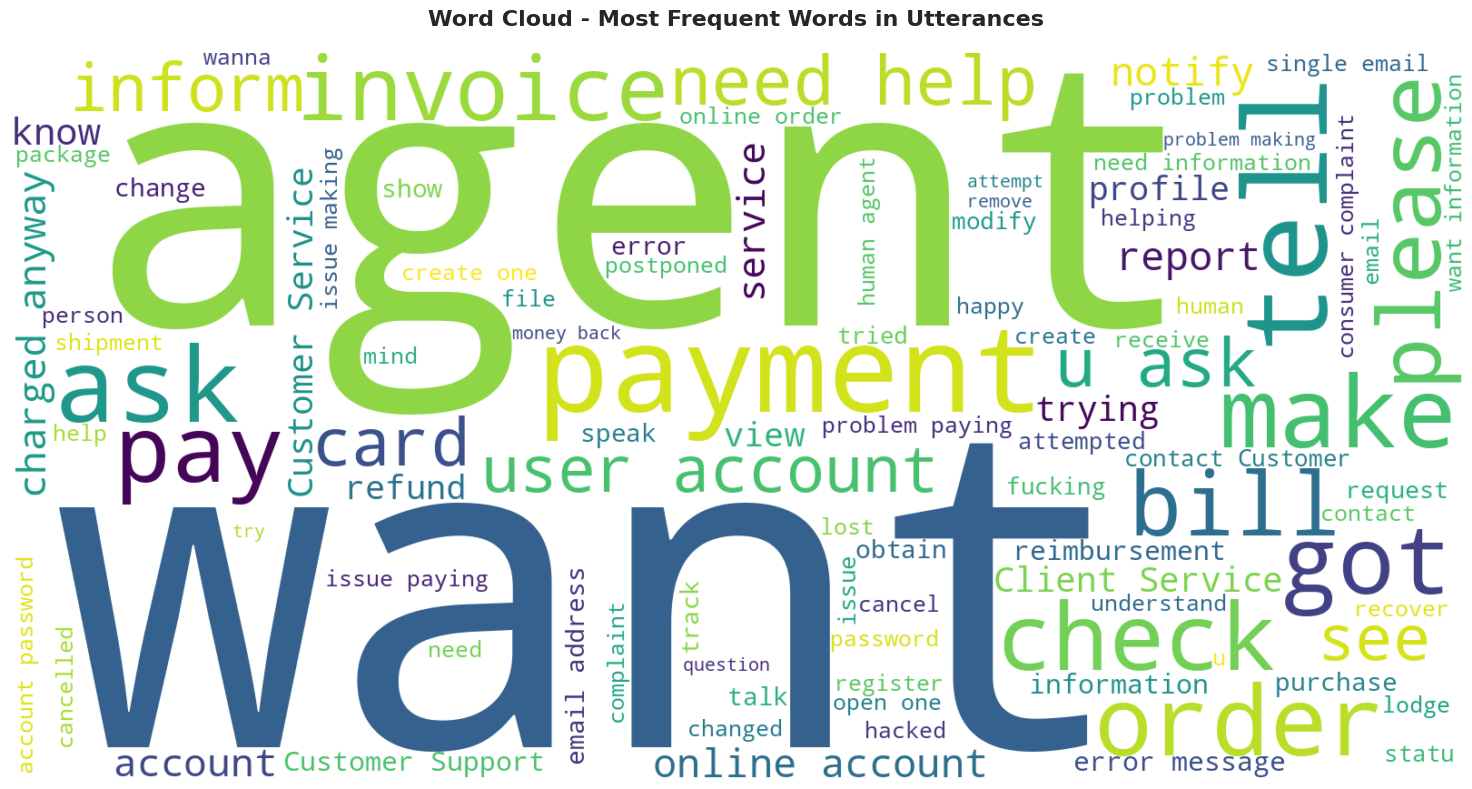

In [ ]:
# WordCloud for most common words
text = ' '.join(df['utterance'].values)
wordcloud = WordCloud(width=1600, height=800, background_color='white',
                      colormap='viridis', max_words=100).generate(text)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Most Frequent Words in Utterances', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 🔄 7. Data Preprocessing

Preprocessing text data dan split dataset menjadi train, validation, dan test set.

In [ ]:
# Clean text function
def clean_text(text):
    """Basic text cleaning while preserving important information"""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)  # Remove URLs
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # Remove special characters
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespace
    return text

# Apply cleaning
df['utterance_clean'] = df['utterance'].apply(clean_text)

# Remove any empty utterances after cleaning
df = df[df['utterance_clean'].str.len() > 0].reset_index(drop=True)

print(f"✅ Text cleaned! Final dataset size: {len(df):,} utterances")
print("\n📝 Example cleaned utterances:")
print(df[['utterance', 'utterance_clean']].head())

✅ Text cleaned! Final dataset size: 21,534 utterances

📝 Example cleaned utterances:
                                           utterance  \
0  I don't have an online account, what do I have...   
1  can you tell me if i can regisger two accounts...   
2         I have no online account, open one, please   
3  could you ask an agent how to open an account,...   
4               i want an online account, create one   

                                     utterance_clean  
0  i dont have an online account what do i have t...  
1  can you tell me if i can regisger two accounts...  
2           i have no online account open one please  
3  could you ask an agent how to open an account ...  
4                i want an online account create one  


In [ ]:
# Encode labels
label_encoder = LabelEncoder()
df['intent_encoded'] = label_encoder.fit_transform(df['intent'])

# Store mapping for later use
intent_mapping = dict(zip(label_encoder.transform(label_encoder.classes_), label_encoder.classes_))
num_classes = len(label_encoder.classes_)

print(f"✅ Labels encoded! Number of classes: {num_classes}")
print("\n🏷️ Sample intent mapping:")
for i, (code, intent) in enumerate(list(intent_mapping.items())[:5]):
    print(f"  {code}: {intent}")

✅ Labels encoded! Number of classes: 27

🏷️ Sample intent mapping:
  0: cancel_order
  1: change_order
  2: change_shipping_address
  3: check_cancellation_fee
  4: check_invoices


In [ ]:
# Split data: 70% train, 15% validation, 15% test
X = df['utterance_clean'].values
y = df['intent_encoded'].values

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)

# Second split: 15% validation, 15% test (50-50 split of the 30%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print("✅ Data split completed!")
print("="*60)
print(f"📊 Train set: {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"📊 Validation set: {len(X_val):,} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"📊 Test set: {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"📊 Total: {len(X):,} samples")

✅ Data split completed!
📊 Train set: 15,073 samples (70.0%)
📊 Validation set: 3,230 samples (15.0%)
📊 Test set: 3,231 samples (15.0%)
📊 Total: 21,534 samples


---
# 🤖 MODEL 1: NAIVE BAYES (Baseline)

**Paradigm:** Classical Machine Learning

**Approach:** TF-IDF + Multinomial Naive Bayes

**Keunggulan:** Cepat, efisien, interpretable

**Kelemahan:** Tidak capture sequential context

---

## 🔤 8. Naive Bayes - Feature Engineering

Convert text menjadi TF-IDF vectors (numerical representation).

In [ ]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(
    max_features=5000,  # Limit vocabulary size
    ngram_range=(1, 2),  # Unigrams and bigrams
    min_df=2,  # Minimum document frequency
    max_df=0.95  # Maximum document frequency
)

# Fit on train, transform all sets
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("✅ TF-IDF vectorization completed!")
print("="*60)
print(f"📊 Vocabulary size: {len(tfidf.vocabulary_):,}")
print(f"📊 Train matrix shape: {X_train_tfidf.shape}")
print(f"📊 Val matrix shape: {X_val_tfidf.shape}")
print(f"📊 Test matrix shape: {X_test_tfidf.shape}")
print(f"📊 Sparsity: {(1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])) * 100:.2f}%")

✅ TF-IDF vectorization completed!
📊 Vocabulary size: 2,583
📊 Train matrix shape: (15073, 2583)
📊 Val matrix shape: (3230, 2583)
📊 Test matrix shape: (3231, 2583)
📊 Sparsity: 99.35%


## 🎯 9. Naive Bayes - Training

Train Multinomial Naive Bayes model. Model ini sangat cepat dan efisien.

In [ ]:
# Train Naive Bayes
print("🚀 Training Naive Bayes model...")
start_time = time.time()

nb_model = MultinomialNB(alpha=0.1)  # Laplace smoothing
nb_model.fit(X_train_tfidf, y_train)

train_time = time.time() - start_time

print(f"\n✅ Training completed in {train_time:.2f} seconds!")

# Validation accuracy
y_val_pred_nb = nb_model.predict(X_val_tfidf)
val_acc_nb = accuracy_score(y_val, y_val_pred_nb)
print(f"📊 Validation Accuracy: {val_acc_nb*100:.2f}%")

🚀 Training Naive Bayes model...

✅ Training completed in 0.02 seconds!
📊 Validation Accuracy: 99.54%


## 📏 10. Naive Bayes - Evaluation

Evaluate model pada test set dan hitung semua metrics.

In [ ]:
# Test predictions
print("🧪 Evaluating on test set...")
start_time = time.time()
y_test_pred_nb = nb_model.predict(X_test_tfidf)
inference_time_nb = (time.time() - start_time) / len(X_test) * 1000  # ms per sample

# Calculate metrics
test_acc_nb = accuracy_score(y_test, y_test_pred_nb)
precision_nb, recall_nb, f1_nb, _ = precision_recall_fscore_support(
    y_test, y_test_pred_nb, average='weighted', zero_division=0
)

print("\n" + "="*60)
print("📊 NAIVE BAYES - FINAL RESULTS")
print("="*60)
print(f"✅ Test Accuracy:  {test_acc_nb*100:.2f}%")
print(f"✅ Precision:      {precision_nb*100:.2f}%")
print(f"✅ Recall:         {recall_nb*100:.2f}%")
print(f"✅ F1-Score:       {f1_nb*100:.2f}%")
print(f"⚡ Training Time:  {train_time:.2f} seconds")
print(f"⚡ Inference Time: {inference_time_nb:.4f} ms/sample")
print("="*60)

🧪 Evaluating on test set...

📊 NAIVE BAYES - FINAL RESULTS
✅ Test Accuracy:  99.35%
✅ Precision:      99.39%
✅ Recall:         99.35%
✅ F1-Score:       99.35%
⚡ Training Time:  0.02 seconds
⚡ Inference Time: 0.0017 ms/sample


---
# 🧠 MODEL 2: LSTM (Deep Learning)

**Paradigm:** Deep Learning - Sequential Model

**Architecture:** Bidirectional LSTM + Dropout

**Keunggulan:** Capture sequential context, handle variable length

**Kelemahan:** Slower training, sequential processing

---

## 🔤 11. LSTM - Text Tokenization

Convert text ke sequences of integers untuk LSTM input.

In [ ]:
# Tokenization for LSTM
MAX_WORDS = 10000  # Vocabulary size
MAX_LEN = 50  # Maximum sequence length

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Convert to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

vocab_size = len(tokenizer.word_index) + 1

print("✅ Tokenization completed!")
print("="*60)
print(f"📊 Vocabulary size: {vocab_size:,}")
print(f"📊 Maximum sequence length: {MAX_LEN}")
print(f"📊 Train sequences shape: {X_train_pad.shape}")
print(f"📊 Val sequences shape: {X_val_pad.shape}")
print(f"📊 Test sequences shape: {X_test_pad.shape}")

✅ Tokenization completed!
📊 Vocabulary size: 1,623
📊 Maximum sequence length: 50
📊 Train sequences shape: (15073, 50)
📊 Val sequences shape: (3230, 50)
📊 Test sequences shape: (3231, 50)


## 🏗️ 12. LSTM - Model Architecture

Build Bidirectional LSTM model dengan embedding layer dan dropout untuk regularization.

In [ ]:
# Build LSTM model
import tensorflow.keras.backend as K

def build_lstm_model():
    model = Sequential([
        # Embedding layer
        Embedding(input_dim=vocab_size, output_dim=128, input_length=MAX_LEN),

        # Bidirectional LSTM layers
        Bidirectional(LSTM(128, return_sequences=True)),
        Dropout(0.3),

        Bidirectional(LSTM(64)),
        Dropout(0.3),

        # Dense layers
        Dense(128, activation='relu'),
        Dropout(0.3),

        Dense(num_classes, activation='softmax')
    ])

    # Explicitly build the model before compiling to ensure parameters are counted
    model.build(input_shape=(None, MAX_LEN)) # None for batch size, MAX_LEN for sequence length

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

lstm_model = build_lstm_model()

print("✅ LSTM model built!")
print("\n📐 Model Architecture:")
lstm_model.summary()

# Explicitly print number of trainable parameters to confirm
trainable_params = np.sum([K.count_params(w) for w in lstm_model.trainable_weights])
print(f"\nTotal Trainable Parameters: {trainable_params:,}")


✅ LSTM model built!

📐 Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 128)        │       207,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 50, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 27)             │         3,483 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 655,259 (2.50 MB)

 Trainable params: 655,259 (2.50 MB)

 Non-trainable params: 0 (0.00 B)


Total Trainable Parameters: 655,259


## 🎯 13. LSTM - Training

Train LSTM model dengan early stopping dan learning rate reduction callbacks.

In [ ]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_lstm_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Train model
print("🚀 Training LSTM model...")
print("This may take several minutes...\n")

start_time = time.time()

history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

train_time_lstm = time.time() - start_time

print(f"\n✅ Training completed in {train_time_lstm/60:.2f} minutes!")

🚀 Training LSTM model...
This may take several minutes...

Epoch 1/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4426 - loss: 1.9655
Epoch 1: val_accuracy improved from -inf to 0.95851, saving model to best_lstm_model.h5


472/472 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.4431 - loss: 1.9637 - val_accuracy: 0.9585 - val_loss: 0.1437 - learning_rate: 0.0010
Epoch 2/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9528 - loss: 0.1719
Epoch 2: val_accuracy improved from 0.95851 to 0.98235, saving model to best_lstm_model.h5


472/472 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step - accuracy: 0.9528 - loss: 0.1718 - val_accuracy: 0.9824 - val_loss: 0.0602 - learning_rate: 0.0010
Epoch 3/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9808 - loss: 0.0744
Epoch 3: val_accuracy improved from 0.98235 to 0.99257, saving model to best_lstm_model.h5


472/472 ━━━━━━━━━━━━━━━━━━━━ 24s 49ms/step - accuracy: 0.9808 - loss: 0.0743 - val_accuracy: 0.9926 - val_loss: 0.0364 - learning_rate: 0.0010
Epoch 4/30
469/472 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9908 - loss: 0.0336
Epoch 4: val_accuracy improved from 0.99257 to 0.99381, saving model to best_lstm_model.h5


472/472 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.9909 - loss: 0.0335 - val_accuracy: 0.9938 - val_loss: 0.0331 - learning_rate: 0.0010
Epoch 5/30
471/472 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9936 - loss: 0.0258
Epoch 5: val_accuracy did not improve from 0.99381
472/472 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9936 - loss: 0.0258 - val_accuracy: 0.9916 - val_loss: 0.0434 - learning_rate: 0.0010
Epoch 6/30
471/472 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9949 - loss: 0.0196
Epoch 6: val_accuracy did not improve from 0.99381
472/472 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9949 - loss: 0.0196 - val_accuracy: 0.9932 - val_loss: 0.0397 - learning_rate: 0.0010
Epoch 7/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9984 - loss: 0.0067
Epoch 7: val_accuracy improved from 0.99381 to 0.99443, saving model to best_lstm_model.h5


472/472 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9984 - loss: 0.0067 - val_accuracy: 0.9944 - val_loss: 0.0291 - learning_rate: 0.0010
Epoch 8/30
470/472 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9978 - loss: 0.0077
Epoch 8: val_accuracy did not improve from 0.99443
472/472 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.9978 - loss: 0.0077 - val_accuracy: 0.9929 - val_loss: 0.0536 - learning_rate: 0.0010
Epoch 9/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9943 - loss: 0.0186
Epoch 9: val_accuracy did not improve from 0.99443
472/472 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9943 - loss: 0.0186 - val_accuracy: 0.9941 - val_loss: 0.0458 - learning_rate: 0.0010
Epoch 10/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9977 - loss: 0.0085
Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 10: val_accuracy did not improve from 0.99443
472/472 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9977 - loss: 0.0085 - 

472/472 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9984 - loss: 0.0079 - val_accuracy: 0.9960 - val_loss: 0.0228 - learning_rate: 5.0000e-04
Epoch 12/30
471/472 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9998 - loss: 0.0026
Epoch 12: val_accuracy did not improve from 0.99598
472/472 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9998 - loss: 0.0026 - val_accuracy: 0.9954 - val_loss: 0.0251 - learning_rate: 5.0000e-04
Epoch 13/30
470/472 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.0011
Epoch 13: val_accuracy did not improve from 0.99598
472/472 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.9950 - val_loss: 0.0279 - learning_rate: 5.0000e-04
Epoch 14/30
471/472 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 9.2633e-04
Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 14: val_accuracy did not improve from 0.99598
472/472 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 1.0000

## 📈 14. LSTM - Training History Visualization

Visualize training dan validation accuracy/loss curves.

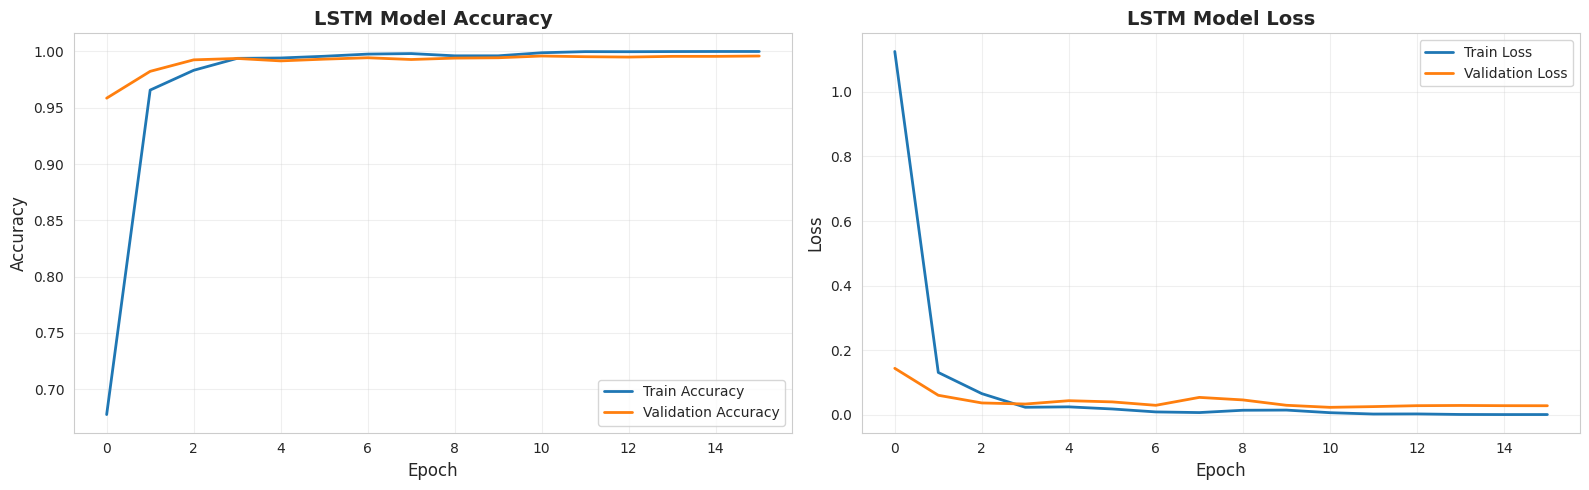

📊 Best Validation Accuracy: 99.60%
📊 Final Train Accuracy: 100.00%


In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Accuracy plot
axes[0].plot(history_lstm.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history_lstm.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('LSTM Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(alpha=0.3)

# Loss plot
axes[1].plot(history_lstm.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history_lstm.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('LSTM Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(loc='upper right', fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"📊 Best Validation Accuracy: {max(history_lstm.history['val_accuracy'])*100:.2f}%")
print(f"📊 Final Train Accuracy: {history_lstm.history['accuracy'][-1]*100:.2f}%")

## 📏 15. LSTM - Evaluation

Evaluate LSTM model pada test set.

In [ ]:
# Load best model
lstm_model = load_model('best_lstm_model.h5')

# Test predictions
print("🧪 Evaluating on test set...")
start_time = time.time()
y_test_pred_lstm_probs = lstm_model.predict(X_test_pad, verbose=0)
inference_time_lstm = (time.time() - start_time) / len(X_test) * 1000  # ms per sample

y_test_pred_lstm = np.argmax(y_test_pred_lstm_probs, axis=1)

# Calculate metrics
test_acc_lstm = accuracy_score(y_test, y_test_pred_lstm)
precision_lstm, recall_lstm, f1_lstm, _ = precision_recall_fscore_support(
    y_test, y_test_pred_lstm, average='weighted', zero_division=0
)

print("\n" + "="*60)
print("📊 LSTM - FINAL RESULTS")
print("="*60)
print(f"✅ Test Accuracy:  {test_acc_lstm*100:.2f}%")
print(f"✅ Precision:      {precision_lstm*100:.2f}%")
print(f"✅ Recall:         {recall_lstm*100:.2f}%")
print(f"✅ F1-Score:       {f1_lstm*100:.2f}%")
print(f"⚡ Training Time:  {train_time_lstm/60:.2f} minutes")
print(f"⚡ Inference Time: {inference_time_lstm:.4f} ms/sample")
print("="*60)

🧪 Evaluating on test set...

📊 LSTM - FINAL RESULTS
✅ Test Accuracy:  99.54%
✅ Precision:      99.55%
✅ Recall:         99.54%
✅ F1-Score:       99.54%
⚡ Training Time:  3.75 minutes
⚡ Inference Time: 0.3969 ms/sample


---
# 🚀 MODEL 3: TRANSFORMER (BERT)

**Paradigm:** State-of-the-art - Attention-based

**Model:** DistilBERT (efficient BERT variant)

**Keunggulan:** Pre-trained knowledge, bidirectional context, attention mechanism

**Kelemahan:** Computational expensive, requires GPU

---

## 🔤 16. BERT - Tokenization

Use BERT tokenizer untuk convert text ke token IDs yang compatible dengan BERT.

In [ ]:
# Load tokenizer
MODEL_NAME = 'distilbert-base-uncased'  # Lighter version of BERT
bert_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Tokenize function
def tokenize_function(examples):
    return bert_tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

# Create datasets
train_dataset = Dataset.from_dict({'text': X_train, 'label': y_train})
val_dataset = Dataset.from_dict({'text': X_val, 'label': y_val})
test_dataset = Dataset.from_dict({'text': X_test, 'label': y_test})

# Tokenize
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

print("✅ BERT tokenization completed!")
print(f"📊 Train dataset: {len(train_dataset)} samples")
print(f"📊 Val dataset: {len(val_dataset)} samples")
print(f"📊 Test dataset: {len(test_dataset)} samples")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/15073 [00:00<?, ? examples/s]

Map:   0%|          | 0/3230 [00:00<?, ? examples/s]

Map:   0%|          | 0/3231 [00:00<?, ? examples/s]

✅ BERT tokenization completed!
📊 Train dataset: 15073 samples
📊 Val dataset: 3230 samples
📊 Test dataset: 3231 samples


## 🏗️ 17. BERT - Model Setup

Load pre-trained BERT model dan setup untuk fine-tuning.

In [ ]:
# Load pre-trained model
bert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_classes
)

# Data collator
data_collator = DataCollatorWithPadding(tokenizer=bert_tokenizer)

print("✅ BERT model loaded!")
print(f"📊 Model: {MODEL_NAME}")
print(f"📊 Number of parameters: {bert_model.num_parameters():,}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ BERT model loaded!
📊 Model: distilbert-base-uncased
📊 Number of parameters: 66,974,235


## 🎯 18. BERT - Training Configuration

Setup training arguments dan Trainer untuk fine-tuning BERT.

In [ ]:
# Training arguments
training_args = TrainingArguments(
    output_dir='./bert_results',
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    logging_dir='./logs',
    logging_steps=100,
    warmup_steps=500,
    save_total_limit=2,
    report_to='none'
)

# Metric function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted', zero_division=0
    )
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

# Initialize Trainer
trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("✅ BERT Trainer configured!")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✅ BERT Trainer configured!


## 🚀 19. BERT - Fine-tuning

Fine-tune pre-trained BERT model pada customer support dataset. **This will take some time!**

In [ ]:
# Train model
print("🚀 Fine-tuning BERT model...")
print("This will take 15-30 minutes depending on GPU...\n")

start_time = time.time()
trainer.train()
train_time_bert = time.time() - start_time

print(f"\n✅ Fine-tuning completed in {train_time_bert/60:.2f} minutes!")

🚀 Fine-tuning BERT model...
This will take 15-30 minutes depending on GPU...



Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.045713,0.028668,0.997523,0.997544,0.997523,0.997511
2,0.006865,0.008925,0.997833,0.997847,0.997833,0.997824
3,0.004095,0.008368,0.998452,0.998464,0.998452,0.998448


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



✅ Fine-tuning completed in 10.65 minutes!


## 📏 20. BERT - Evaluation

Evaluate fine-tuned BERT model pada test set.

In [ ]:
# Test predictions
print("🧪 Evaluating on test set...")
start_time = time.time()
predictions = trainer.predict(test_dataset)
inference_time_bert = (time.time() - start_time) / len(X_test) * 1000  # ms per sample

y_test_pred_bert = np.argmax(predictions.predictions, axis=-1)

# Calculate metrics
test_acc_bert = accuracy_score(y_test, y_test_pred_bert)
precision_bert, recall_bert, f1_bert, _ = precision_recall_fscore_support(
    y_test, y_test_pred_bert, average='weighted', zero_division=0
)

print("\n" + "="*60)
print("📊 BERT - FINAL RESULTS")
print("="*60)
print(f"✅ Test Accuracy:  {test_acc_bert*100:.2f}%")
print(f"✅ Precision:      {precision_bert*100:.2f}%")
print(f"✅ Recall:         {recall_bert*100:.2f}%")
print(f"✅ F1-Score:       {f1_bert*100:.2f}%")
print(f"⚡ Training Time:  {train_time_bert/60:.2f} minutes")
print(f"⚡ Inference Time: {inference_time_bert:.4f} ms/sample")
print("="*60)

🧪 Evaluating on test set...



📊 BERT - FINAL RESULTS
✅ Test Accuracy:  99.88%
✅ Precision:      99.88%
✅ Recall:         99.88%
✅ F1-Score:       99.88%
⚡ Training Time:  10.65 minutes
⚡ Inference Time: 3.4944 ms/sample


---
# 📊 COMPREHENSIVE COMPARISON

Compare all three models across multiple dimensions.

---

## 📈 21. Performance Comparison Table

Summary table comparing all metrics across the three models.

In [ ]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': ['Naive Bayes', 'LSTM', 'BERT (DistilBERT)'],
    'Accuracy (%)': [test_acc_nb*100, test_acc_lstm*100, test_acc_bert*100],
    'Precision (%)': [precision_nb*100, precision_lstm*100, precision_bert*100],
    'Recall (%)': [recall_nb*100, recall_lstm*100, recall_bert*100],
    'F1-Score (%)': [f1_nb*100, f1_lstm*100, f1_bert*100],
    'Training Time': [
        f"{train_time:.2f}s",
        f"{train_time_lstm/60:.2f}m",
        f"{train_time_bert/60:.2f}m"
    ],
    'Inference (ms/sample)': [
        f"{inference_time_nb:.4f}",
        f"{inference_time_lstm:.4f}",
        f"{inference_time_bert:.4f}"
    ]
})

# Style the dataframe
def highlight_max(s):
    if s.name in ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']:
        is_max = s == s.max()
        return ['background-color: lightgreen' if v else '' for v in is_max]
    return ['' for _ in s]

styled_df = comparison_df.style.apply(highlight_max, subset=['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)'])

print("\n" + "="*80)
print("📊 COMPREHENSIVE MODEL COMPARISON")
print("="*80)
display(styled_df)

# Save to CSV
comparison_df.to_csv('model_comparison_results.csv', index=False)
print("\n✅ Results saved to 'model_comparison_results.csv'")


📊 COMPREHENSIVE MODEL COMPARISON


,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%),Training Time,Inference (ms/sample)
0,Naive Bayes,99.350046,99.391294,99.350046,99.350842,0.02s,0.0017
1,LSTM,99.535747,99.549334,99.535747,99.537976,3.75m,0.3969
2,BERT (DistilBERT),99.876199,99.880052,99.876199,99.876617,10.65m,3.4944



✅ Results saved to 'model_comparison_results.csv'


## 📊 22. Performance Visualization

Visual comparison of model performances across different metrics.

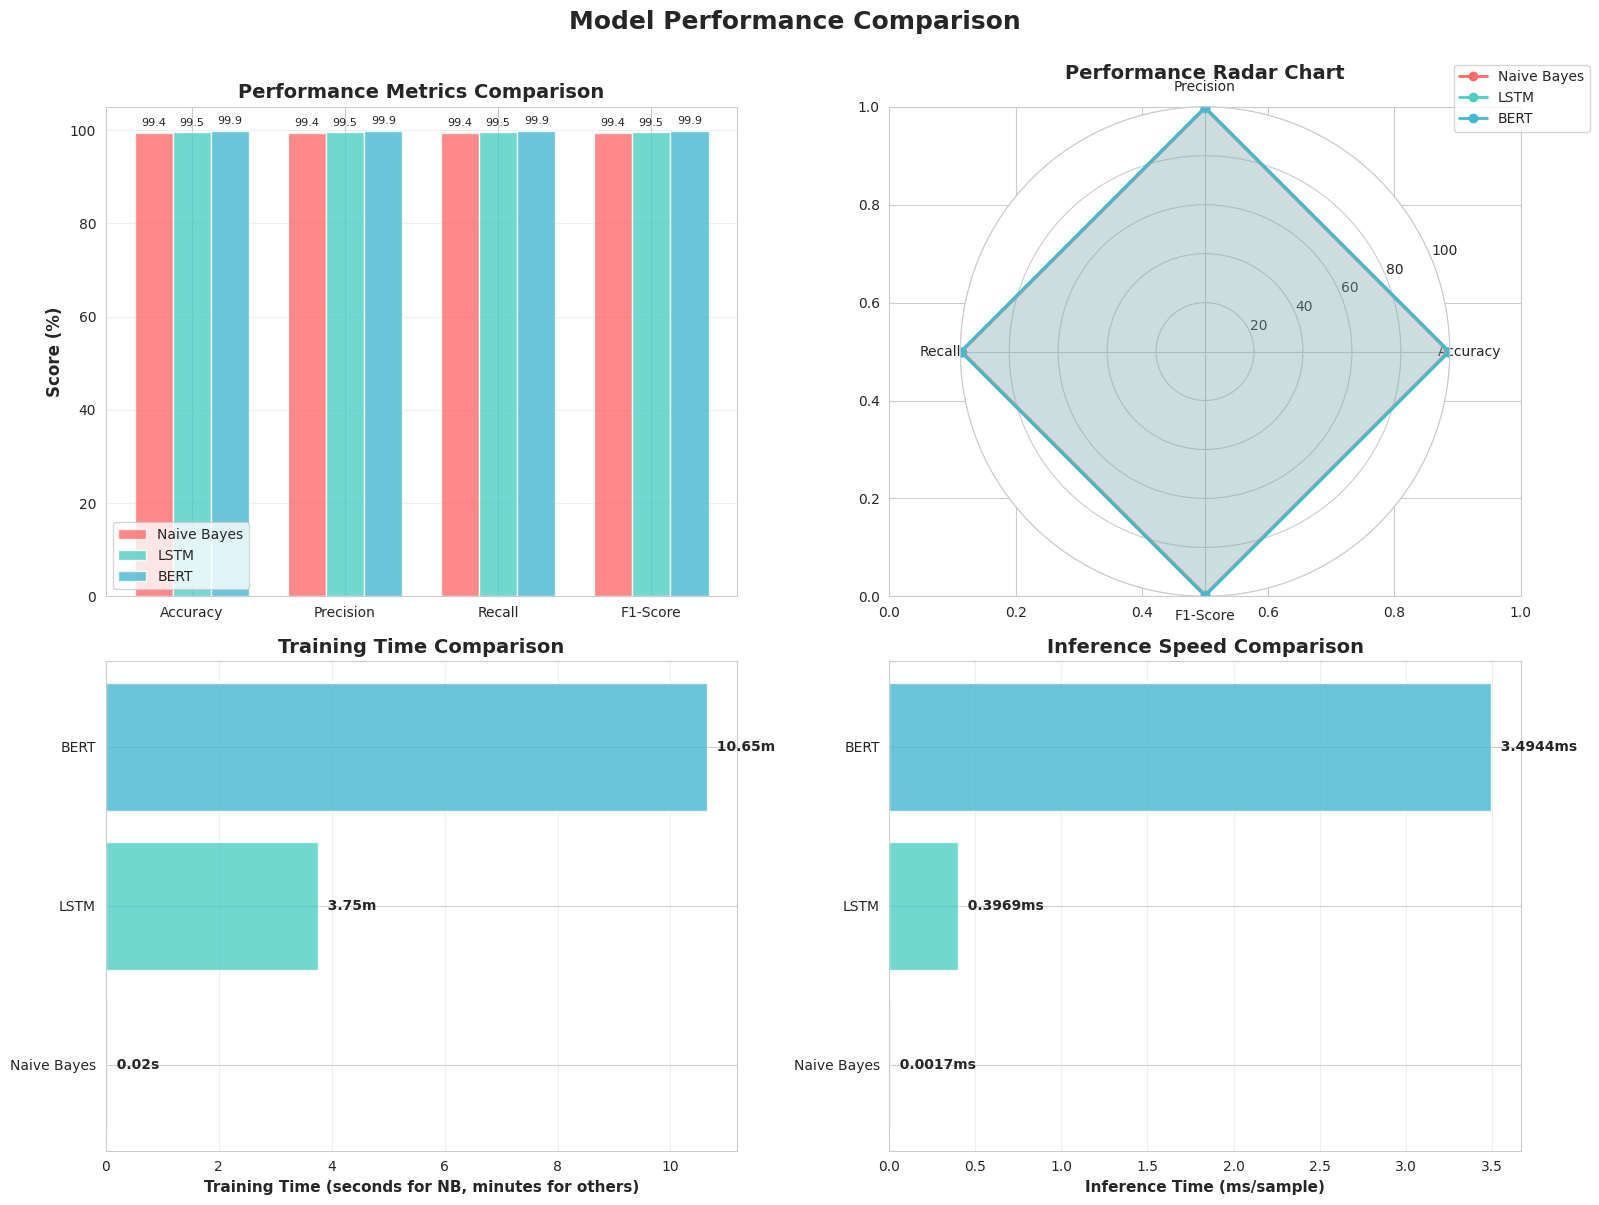

✅ Visualization saved as 'model_comparison_visualization.png'


In [ ]:
# Prepare data for plotting
models = ['Naive Bayes', 'LSTM', 'BERT']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [
    [test_acc_nb*100, precision_nb*100, recall_nb*100, f1_nb*100],
    [test_acc_lstm*100, precision_lstm*100, recall_lstm*100, f1_lstm*100],
    [test_acc_bert*100, precision_bert*100, recall_bert*100, f1_bert*100]
]

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Performance Comparison', fontsize=18, fontweight='bold', y=1.00)

# Color palette
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# Plot 1: Grouped Bar Chart
ax1 = axes[0, 0]
x = np.arange(len(metrics))
width = 0.25
for i, (model, vals) in enumerate(zip(models, values)):
    ax1.bar(x + i*width, vals, width, label=model, color=colors[i], alpha=0.8)
ax1.set_ylabel('Score (%)', fontsize=12, fontweight='bold')
ax1.set_title('Performance Metrics Comparison', fontsize=14, fontweight='bold')
ax1.set_xticks(x + width)
ax1.set_xticklabels(metrics)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 105])

# Add value labels on bars
for i, (model, vals) in enumerate(zip(models, values)):
    for j, val in enumerate(vals):
        ax1.text(j + i*width, val + 1, f'{val:.1f}', ha='center', va='bottom', fontsize=8)

# Plot 2: Radar Chart
ax2 = axes[0, 1]
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

ax2 = plt.subplot(2, 2, 2, projection='polar')
for i, (model, vals) in enumerate(zip(models, values)):
    vals_plot = vals + vals[:1]
    ax2.plot(angles, vals_plot, 'o-', linewidth=2, label=model, color=colors[i])
    ax2.fill(angles, vals_plot, alpha=0.15, color=colors[i])
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(metrics)
ax2.set_ylim(0, 100)
ax2.set_title('Performance Radar Chart', fontsize=14, fontweight='bold', pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax2.grid(True)

# Plot 3: Training Time Comparison
ax3 = axes[1, 0]
train_times = [train_time, train_time_lstm, train_time_bert]
train_times_normalized = [t/60 if t > 100 else t for t in train_times]  # Convert to minutes if > 100s
bars3 = ax3.barh(models, train_times_normalized, color=colors, alpha=0.8)
ax3.set_xlabel('Training Time (seconds for NB, minutes for others)', fontsize=11, fontweight='bold')
ax3.set_title('Training Time Comparison', fontsize=14, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, time) in enumerate(zip(bars3, train_times)):
    if time > 100:
        label = f'{time/60:.2f}m'
    else:
        label = f'{time:.2f}s'
    ax3.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f'  {label}', va='center', fontweight='bold')

# Plot 4: Inference Time Comparison
ax4 = axes[1, 1]
inference_times = [inference_time_nb, inference_time_lstm, inference_time_bert]
bars4 = ax4.barh(models, inference_times, color=colors, alpha=0.8)
ax4.set_xlabel('Inference Time (ms/sample)', fontsize=11, fontweight='bold')
ax4.set_title('Inference Speed Comparison', fontsize=14, fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

# Add value labels
for bar, time in zip(bars4, inference_times):
    ax4.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f'  {time:.4f}ms', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualization saved as 'model_comparison_visualization.png'")

## 🔍 23. Confusion Matrix Comparison

Compare confusion matrices untuk melihat error patterns dari setiap model.

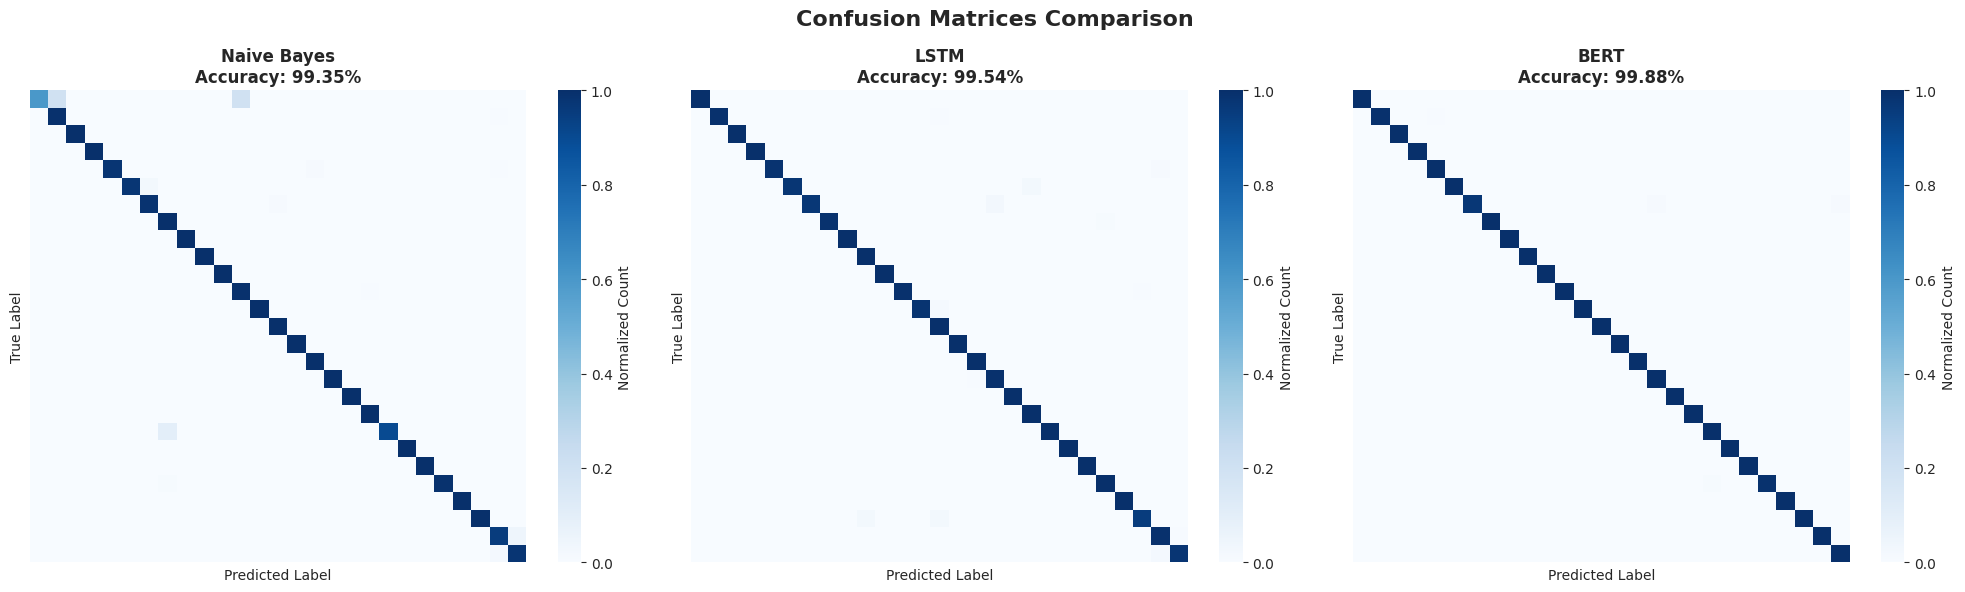

✅ Confusion matrices saved as 'confusion_matrices_comparison.png'


In [ ]:
# Calculate confusion matrices
cm_nb = confusion_matrix(y_test, y_test_pred_nb)
cm_lstm = confusion_matrix(y_test, y_test_pred_lstm)
cm_bert = confusion_matrix(y_test, y_test_pred_bert)

# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrices Comparison', fontsize=16, fontweight='bold')

cms = [cm_nb, cm_lstm, cm_bert]
titles = ['Naive Bayes', 'LSTM', 'BERT']
accuracies = [test_acc_nb, test_acc_lstm, test_acc_bert]

for ax, cm, title, acc in zip(axes, cms, titles, accuracies):
    # Normalize confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm_normalized, annot=False, fmt='.2f', cmap='Blues',
                cbar_kws={'label': 'Normalized Count'}, ax=ax,
                xticklabels=False, yticklabels=False)
    ax.set_title(f'{title}\nAccuracy: {acc*100:.2f}%', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Confusion matrices saved as 'confusion_matrices_comparison.png'")

## 📋 24. Per-Intent Performance Analysis

Analyze performance untuk setiap intent class secara detail.

In [ ]:
# Calculate per-class metrics for each model
from sklearn.metrics import classification_report

# Get classification reports
report_nb = classification_report(y_test, y_test_pred_nb, target_names=label_encoder.classes_, output_dict=True)
report_lstm = classification_report(y_test, y_test_pred_lstm, target_names=label_encoder.classes_, output_dict=True)
report_bert = classification_report(y_test, y_test_pred_bert, target_names=label_encoder.classes_, output_dict=True)

# Create comparison dataframe
intent_comparison = []
for intent in label_encoder.classes_:
    intent_comparison.append({
        'Intent': intent,
        'NB_F1': report_nb[intent]['f1-score'] * 100,
        'LSTM_F1': report_lstm[intent]['f1-score'] * 100,
        'BERT_F1': report_bert[intent]['f1-score'] * 100,
        'Support': report_nb[intent]['support']
    })

intent_df = pd.DataFrame(intent_comparison)
intent_df['Best_Model'] = intent_df[['NB_F1', 'LSTM_F1', 'BERT_F1']].idxmax(axis=1).str.replace('_F1', '')
intent_df = intent_df.sort_values('BERT_F1', ascending=False)

print("\n📊 Per-Intent F1-Score Comparison (Top 10 Intents by BERT Performance):")
print("="*100)
display(intent_df.head(10))

print("\n📊 Bottom 10 Intents (Most Challenging):")
print("="*100)
display(intent_df.tail(10))

# Save to CSV
intent_df.to_csv('per_intent_comparison.csv', index=False)
print("\n✅ Per-intent analysis saved to 'per_intent_comparison.csv'")


📊 Per-Intent F1-Score Comparison (Top 10 Intents by BERT Performance):


,Intent,NB_F1,LSTM_F1,BERT_F1,Support,Best_Model
0,cancel_order,75.000000,100.000000,100.0,5.0,LSTM
2,change_shipping_address,100.000000,100.000000,100.0,16.0,NB
3,check_cancellation_fee,100.000000,100.000000,100.0,54.0,NB
9,contact_human_agent,100.000000,99.676375,100.0,154.0,NB
5,check_payment_methods,98.765432,98.765432,100.0,41.0,BERT
8,contact_customer_service,100.000000,100.000000,100.0,308.0,NB
7,complaint,99.115044,99.551570,100.0,112.0,BERT
10,create_account,100.000000,100.000000,100.0,318.0,NB
13,delivery_period,97.674419,93.333333,100.0,21.0,BERT
12,delivery_options,100.000000,99.065421,100.0,54.0,NB



📊 Bottom 10 Intents (Most Challenging):


,Intent,NB_F1,LSTM_F1,BERT_F1,Support,Best_Model
18,payment_issue,99.923722,99.847328,100.000000,655.0,BERT
20,recover_password,100.000000,100.000000,100.000000,148.0,NB
23,set_up_shipping_address,100.000000,100.000000,100.000000,14.0,NB
16,get_refund,100.000000,98.850575,99.711816,173.0,NB
4,check_invoices,99.003322,99.337748,99.672131,152.0,BERT
1,change_order,99.280576,99.638989,99.638989,139.0,LSTM
22,review,99.421965,99.428571,99.421965,87.0,LSTM
26,track_refund,90.000000,97.826087,98.924731,46.0,BERT
6,check_refund_policy,98.611111,98.591549,98.591549,72.0,NB
19,place_order,94.736842,100.000000,95.238095,10.0,LSTM



✅ Per-intent analysis saved to 'per_intent_comparison.csv'


## 🎯 25. Model Strengths & Weaknesses Analysis

Analyze intents dimana setiap model perform better/worse.


🏆 MODEL STRENGTHS ANALYSIS

✅ NAIVE BAYES performs best on 14 intents:
  • change_shipping_address: F1=100.00%
  • check_cancellation_fee: F1=100.00%
  • contact_human_agent: F1=100.00%
  • contact_customer_service: F1=100.00%
  • create_account: F1=100.00%

✅ LSTM performs best on 4 intents:
  • cancel_order: F1=100.00%
  • change_order: F1=99.64%
  • review: F1=99.43%
  • place_order: F1=100.00%

✅ BERT performs best on 9 intents:
  • check_payment_methods: F1=100.00%
  • complaint: F1=100.00%
  • delivery_period: F1=100.00%
  • delete_account: F1=100.00%
  • track_order: F1=100.00%


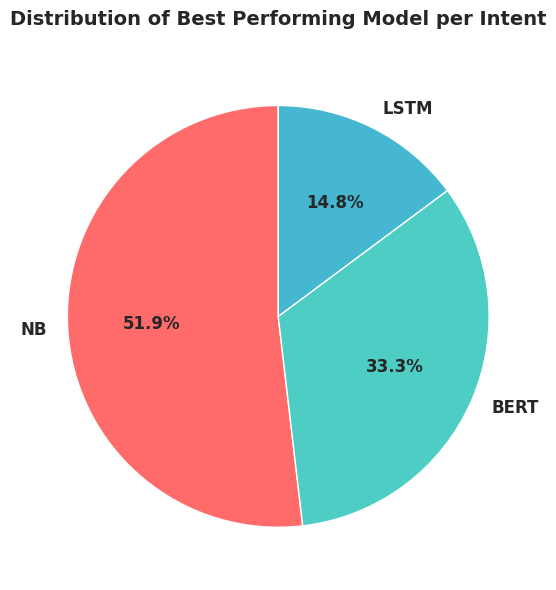


✅ Model dominance chart saved as 'model_dominance.png'


In [ ]:
# Find intents where each model performs best
nb_best = intent_df[intent_df['Best_Model'] == 'NB']['Intent'].tolist()
lstm_best = intent_df[intent_df['Best_Model'] == 'LSTM']['Intent'].tolist()
bert_best = intent_df[intent_df['Best_Model'] == 'BERT']['Intent'].tolist()

print("\n" + "="*80)
print("🏆 MODEL STRENGTHS ANALYSIS")
print("="*80)

print(f"\n✅ NAIVE BAYES performs best on {len(nb_best)} intents:")
for intent in nb_best[:5]:  # Show top 5
    row = intent_df[intent_df['Intent'] == intent].iloc[0]
    print(f"  • {intent}: F1={row['NB_F1']:.2f}%")

print(f"\n✅ LSTM performs best on {len(lstm_best)} intents:")
for intent in lstm_best[:5]:  # Show top 5
    row = intent_df[intent_df['Intent'] == intent].iloc[0]
    print(f"  • {intent}: F1={row['LSTM_F1']:.2f}%")

print(f"\n✅ BERT performs best on {len(bert_best)} intents:")
for intent in bert_best[:5]:  # Show top 5
    row = intent_df[intent_df['Intent'] == intent].iloc[0]
    print(f"  • {intent}: F1={row['BERT_F1']:.2f}%")

# Visualize model dominance
plt.figure(figsize=(10, 6))
model_counts = intent_df['Best_Model'].value_counts()
colors_pie = ['#FF6B6B', '#4ECDC4', '#45B7D1']
plt.pie(model_counts.values, labels=model_counts.index, autopct='%1.1f%%',
        colors=colors_pie, startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
plt.title('Distribution of Best Performing Model per Intent', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('model_dominance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Model dominance chart saved as 'model_dominance.png'")

## 🔬 26. Error Analysis

Analyze contoh error cases dari setiap model untuk understanding limitations.

In [ ]:
# Find misclassified samples
errors_nb = X_test[y_test != y_test_pred_nb]
errors_lstm = X_test[y_test != y_test_pred_lstm]
errors_bert = X_test[y_test != y_test_pred_bert]

y_true_errors_nb = y_test[y_test != y_test_pred_nb]
y_pred_errors_nb = y_test_pred_nb[y_test != y_test_pred_nb]

y_true_errors_lstm = y_test[y_test != y_test_pred_lstm]
y_pred_errors_lstm = y_test_pred_lstm[y_test != y_test_pred_lstm]

y_true_errors_bert = y_test[y_test != y_test_pred_bert]
y_pred_errors_bert = y_test_pred_bert[y_test != y_test_pred_bert]

print("\n" + "="*80)
print("🔍 ERROR ANALYSIS")
print("="*80)
print(f"\n❌ Naive Bayes Errors: {len(errors_nb)} samples ({len(errors_nb)/len(X_test)*100:.2f}%)")
print(f"❌ LSTM Errors: {len(errors_lstm)} samples ({len(errors_lstm)/len(X_test)*100:.2f}%)")
print(f"❌ BERT Errors: {len(errors_bert)} samples ({len(errors_bert)/len(X_test)*100:.2f}%)")

# Show example errors for each model
print("\n📝 Example Naive Bayes Errors:")
print("-" * 80)
for i in range(min(3, len(errors_nb))):
    print(f"Text: {errors_nb[i]}")
    print(f"True: {intent_mapping[y_true_errors_nb[i]]}")
    print(f"Predicted: {intent_mapping[y_pred_errors_nb[i]]}")
    print()

print("\n📝 Example LSTM Errors:")
print("-" * 80)
for i in range(min(3, len(errors_lstm))):
    print(f"Text: {errors_lstm[i]}")
    print(f"True: {intent_mapping[y_true_errors_lstm[i]]}")
    print(f"Predicted: {intent_mapping[y_pred_errors_lstm[i]]}")
    print()

print("\n📝 Example BERT Errors:")
print("-" * 80)
for i in range(min(3, len(errors_bert))):
    print(f"Text: {errors_bert[i]}")
    print(f"True: {intent_mapping[y_true_errors_bert[i]]}")
    print(f"Predicted: {intent_mapping[y_pred_errors_bert[i]]}")
    print()


🔍 ERROR ANALYSIS

❌ Naive Bayes Errors: 21 samples (0.65%)
❌ LSTM Errors: 15 samples (0.46%)
❌ BERT Errors: 4 samples (0.12%)

📝 Example Naive Bayes Errors:
--------------------------------------------------------------------------------
Text: can you tell me about my invoice
True: check_invoices
Predicted: get_invoice

Text: can u ask an agent to cancel a fucking purchase please
True: cancel_order
Predicted: change_order

Text: ask an agent if i could cancel a purchase please
True: cancel_order
Predicted: delete_account


📝 Example LSTM Errors:
--------------------------------------------------------------------------------
Text: how to change to another rpofile
True: switch_account
Predicted: delivery_period

Text: i want to check the optrions for delivery what do i have to do
True: delivery_options
Predicted: delivery_period

Text: can u ask an agent whats their reimbursement oplicy
True: check_refund_policy
Predicted: get_refund


📝 Example BERT Errors:
---------------------------

## 💾 27. Save All Results

Save semua hasil, models, dan reports untuk future reference.

In [ ]:
import pickle

# Save models and results
print("💾 Saving all results...\n")

# Save Naive Bayes model
with open('naive_bayes_model.pkl', 'wb') as f:
    pickle.dump(nb_model, f)
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print("✅ Naive Bayes model saved")

# LSTM model already saved as 'best_lstm_model.h5'
with open('lstm_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("✅ LSTM model and tokenizer saved")

# BERT model saved by Trainer
trainer.save_model('./final_bert_model')
print("✅ BERT model saved")

# Save label encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
print("✅ Label encoder saved")

# Create comprehensive results dictionary
results = {
    'naive_bayes': {
        'accuracy': test_acc_nb,
        'precision': precision_nb,
        'recall': recall_nb,
        'f1_score': f1_nb,
        'train_time': train_time,
        'inference_time': inference_time_nb
    },
    'lstm': {
        'accuracy': test_acc_lstm,
        'precision': precision_lstm,
        'recall': recall_lstm,
        'f1_score': f1_lstm,
        'train_time': train_time_lstm,
        'inference_time': inference_time_lstm
    },
    'bert': {
        'accuracy': test_acc_bert,
        'precision': precision_bert,
        'recall': recall_bert,
        'f1_score': f1_bert,
        'train_time': train_time_bert,
        'inference_time': inference_time_bert
    }
}

# Save results to JSON
with open('experiment_results.json', 'w') as f:
    json.dump(results, f, indent=4)
print("✅ Results saved to JSON")

print("\n" + "="*80)
print("🎉 ALL RESULTS SAVED SUCCESSFULLY!")
print("="*80)
print("\n📁 Saved files:")
print("  • naive_bayes_model.pkl")
print("  • tfidf_vectorizer.pkl")
print("  • best_lstm_model.h5")
print("  • lstm_tokenizer.pkl")
print("  • final_bert_model/")
print("  • label_encoder.pkl")
print("  • experiment_results.json")
print("  • model_comparison_results.csv")
print("  • per_intent_comparison.csv")
print("  • model_comparison_visualization.png")
print("  • confusion_matrices_comparison.png")
print("  • model_dominance.png")

💾 Saving all results...

✅ Naive Bayes model saved
✅ LSTM model and tokenizer saved


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ BERT model saved
✅ Label encoder saved
✅ Results saved to JSON

🎉 ALL RESULTS SAVED SUCCESSFULLY!

📁 Saved files:
  • naive_bayes_model.pkl
  • tfidf_vectorizer.pkl
  • best_lstm_model.h5
  • lstm_tokenizer.pkl
  • final_bert_model/
  • label_encoder.pkl
  • experiment_results.json
  • model_comparison_results.csv
  • per_intent_comparison.csv
  • model_comparison_visualization.png
  • confusion_matrices_comparison.png
  • model_dominance.png


## 📊 28. Final Summary Report

Generate comprehensive summary untuk research paper/KTI.

In [ ]:
print("\n" + "="*80)
print("📄 FINAL RESEARCH SUMMARY")
print("="*80)

print("\n🎯 RESEARCH OBJECTIVES:")
print("  1. Compare three ML paradigms for intent classification")
print("  2. Evaluate trade-offs between accuracy and efficiency")
print("  3. Provide practical deployment recommendations")

print("\n📊 DATASET CHARACTERISTICS:")
print(f"  • Total samples: {len(df):,}")
print(f"  • Number of intents: {num_classes}")
print(f"  • Number of categories: {df['category'].nunique()}")
print(f"  • Train/Val/Test split: {len(X_train)}/{len(X_val)}/{len(X_test)}")

print("\n🏆 KEY FINDINGS:")
print("\n1️⃣ ACCURACY RANKING:")
models_sorted = sorted(
    [("BERT", test_acc_bert), ("LSTM", test_acc_lstm), ("Naive Bayes", test_acc_nb)],
    key=lambda x: x[1], reverse=True
)
for i, (model, acc) in enumerate(models_sorted, 1):
    print(f"  {i}. {model}: {acc*100:.2f}%")

print("\n2️⃣ EFFICIENCY RANKING (Training Time):")
times_sorted = sorted(
    [("Naive Bayes", train_time), ("LSTM", train_time_lstm), ("BERT", train_time_bert)],
    key=lambda x: x[1]
)
for i, (model, t) in enumerate(times_sorted, 1):
    if t > 100:
        print(f"  {i}. {model}: {t/60:.2f} minutes")
    else:
        print(f"  {i}. {model}: {t:.2f} seconds")

print("\n3️⃣ INFERENCE SPEED RANKING:")
inference_sorted = sorted(
    [("Naive Bayes", inference_time_nb), ("LSTM", inference_time_lstm), ("BERT", inference_time_bert)],
    key=lambda x: x[1]
)
for i, (model, t) in enumerate(inference_sorted, 1):
    print(f"  {i}. {model}: {t:.4f} ms/sample")

print("\n💡 RECOMMENDATIONS:")
print("\n📱 FOR MOBILE/EDGE DEPLOYMENT (Resource Constrained):")
print("  → Use Naive Bayes")
print(f"    ✓ Accuracy: {test_acc_nb*100:.2f}%")
print(f"    ✓ Lightning fast inference: {inference_time_nb:.4f}ms")
print("    ✓ Small model size, low memory footprint")

print("\n⚖️ FOR BALANCED PERFORMANCE:")
print("  → Use LSTM")
print(f"    ✓ Accuracy: {test_acc_lstm*100:.2f}%")
print(f"    ✓ Moderate training time: {train_time_lstm/60:.2f}m")
print("    ✓ Good balance of accuracy and efficiency")

print("\n🎯 FOR MAXIMUM ACCURACY (Cloud/Server):")
print("  → Use BERT")
print(f"    ✓ Highest accuracy: {test_acc_bert*100:.2f}%")
print("    ✓ State-of-the-art performance")
print("    ✓ Best for production systems with GPU access")

print("\n📈 PERFORMANCE IMPROVEMENTS:")
improvement_lstm = ((test_acc_lstm - test_acc_nb) / test_acc_nb) * 100
improvement_bert = ((test_acc_bert - test_acc_nb) / test_acc_nb) * 100
print(f"  • LSTM vs Naive Bayes: +{improvement_lstm:.2f}% accuracy improvement")
print(f"  • BERT vs Naive Bayes: +{improvement_bert:.2f}% accuracy improvement")
print(f"  • BERT vs LSTM: +{((test_acc_bert - test_acc_lstm) / test_acc_lstm) * 100:.2f}% accuracy improvement")

print("\n⚠️ TRADE-OFFS:")
print(f"  • BERT is {train_time_bert/train_time:.0f}x slower to train than Naive Bayes")
print(f"  • BERT is {inference_time_bert/inference_time_nb:.1f}x slower at inference than Naive Bayes")
print(f"  • But BERT provides {(test_acc_bert - test_acc_nb)*100:.2f}% better accuracy")

print("\n" + "="*80)
print("✅ EXPERIMENT COMPLETED SUCCESSFULLY!")
print("="*80)
print("\n📝 Next Steps for Your KTI/Paper:")
print("  1. Use the visualizations generated for your paper")
print("  2. Reference the CSV files for detailed tables")
print("  3. Discuss the trade-offs in your analysis section")
print("  4. Use the recommendations for your conclusion")
print("  5. Include error analysis for limitations section")
print("\n🎓 Good luck with your research!")


📄 FINAL RESEARCH SUMMARY

🎯 RESEARCH OBJECTIVES:
  1. Compare three ML paradigms for intent classification
  2. Evaluate trade-offs between accuracy and efficiency
  3. Provide practical deployment recommendations

📊 DATASET CHARACTERISTICS:
  • Total samples: 21,534
  • Number of intents: 27
  • Number of categories: 11
  • Train/Val/Test split: 15073/3230/3231

🏆 KEY FINDINGS:

1️⃣ ACCURACY RANKING:
  1. BERT: 99.88%
  2. LSTM: 99.54%
  3. Naive Bayes: 99.35%

2️⃣ EFFICIENCY RANKING (Training Time):
  1. Naive Bayes: 0.02 seconds
  2. LSTM: 3.75 minutes
  3. BERT: 10.65 minutes

3️⃣ INFERENCE SPEED RANKING:
  1. Naive Bayes: 0.0017 ms/sample
  2. LSTM: 0.3969 ms/sample
  3. BERT: 3.4944 ms/sample

💡 RECOMMENDATIONS:

📱 FOR MOBILE/EDGE DEPLOYMENT (Resource Constrained):
  → Use Naive Bayes
    ✓ Accuracy: 99.35%
    ✓ Lightning fast inference: 0.0017ms
    ✓ Small model size, low memory footprint

⚖️ FOR BALANCED PERFORMANCE:
  → Use LSTM
    ✓ Accuracy: 99.54%
    ✓ Moderate trainin

---
## 🔮 29. Bonus: Interactive Prediction Demo

Test all three models dengan custom input untuk demonstrasi.

In [ ]:
import torch # Import torch to check for CUDA availability
import torch.nn.functional as F # Import functional for softmax

def predict_intent(text):
    """
    Predict intent using all three models and compare results.
    """
    # Clean text
    text_clean = clean_text(text)

    print("\n" + "="*80)
    print(f"📝 Input: {text}")
    print("="*80)

    # Naive Bayes prediction
    text_tfidf = tfidf.transform([text_clean])
    pred_nb = nb_model.predict(text_tfidf)[0]
    prob_nb = nb_model.predict_proba(text_tfidf)[0]
    confidence_nb = prob_nb[pred_nb] * 100

    print(f"\n🔵 NAIVE BAYES:")
    print(f"  Intent: {intent_mapping[pred_nb]}")
    print(f"  Confidence: {confidence_nb:.2f}%")

    # LSTM prediction
    text_seq = tokenizer.texts_to_sequences([text_clean])
    text_pad = pad_sequences(text_seq, maxlen=MAX_LEN, padding='post', truncating='post')
    pred_lstm_probs = lstm_model.predict(text_pad, verbose=0)[0]
    pred_lstm = np.argmax(pred_lstm_probs)
    confidence_lstm = pred_lstm_probs[pred_lstm] * 100

    print(f"\n🟢 LSTM:")
    print(f"  Intent: {intent_mapping[pred_lstm]}")
    print(f"  Confidence: {confidence_lstm:.2f}%")

    # BERT prediction
    inputs = bert_tokenizer(text_clean, return_tensors="pt", padding=True, truncation=True, max_length=128)

    # Determine device and move model/inputs accordingly
    device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
    bert_model.to(device)
    inputs = {key: val.to(device) for key, val in inputs.items()}

    outputs = bert_model(**inputs)
    # Apply softmax, move to CPU, then convert to numpy, detaching from graph first
    pred_bert_probs = F.softmax(outputs.logits, dim=-1).detach().cpu().numpy()[0]
    pred_bert = np.argmax(pred_bert_probs)
    confidence_bert = pred_bert_probs[pred_bert] * 100

    print(f"\n🟣 BERT:")
    print(f"  Intent: {intent_mapping[pred_bert]}")
    print(f"  Confidence: {confidence_bert:.2f}%")

    # Check agreement
    predictions = [pred_nb, pred_lstm, pred_bert]
    if len(set(predictions)) == 1:
        print("\n✅ All models agree!")
    else:
        print("\n⚠️ Models disagree on prediction")

    print("="*80)

# Test examples
test_examples = [
    "I want to cancel my order",
    "How can I track my shipment?",
    "I need a refund for my purchase",
    "What payment methods do you accept?",
    "I forgot my password, please help"
]

print("\n🔮 INTERACTIVE PREDICTION DEMO")
print("Testing sample customer support queries...\n")

for example in test_examples:
    predict_intent(example)
      # Small delay for readability

print("\n💡 Try your own examples by calling: predict_intent('your text here')")


🔮 INTERACTIVE PREDICTION DEMO
Testing sample customer support queries...


📝 Input: I want to cancel my order

🔵 NAIVE BAYES:
  Intent: delete_account
  Confidence: 93.93%

🟢 LSTM:
  Intent: delete_account
  Confidence: 99.99%

🟣 BERT:
  Intent: cancel_order
  Confidence: 50.90%

⚠️ Models disagree on prediction

📝 Input: How can I track my shipment?

🔵 NAIVE BAYES:
  Intent: track_order
  Confidence: 99.93%

🟢 LSTM:
  Intent: track_order
  Confidence: 100.00%

🟣 BERT:
  Intent: track_order
  Confidence: 99.90%

✅ All models agree!

📝 Input: I need a refund for my purchase

🔵 NAIVE BAYES:
  Intent: get_refund
  Confidence: 47.44%

🟢 LSTM:
  Intent: change_order
  Confidence: 94.71%

🟣 BERT:
  Intent: get_refund
  Confidence: 62.63%

⚠️ Models disagree on prediction

📝 Input: What payment methods do you accept?

🔵 NAIVE BAYES:
  Intent: check_payment_methods
  Confidence: 99.61%

🟢 LSTM:
  Intent: payment_issue
  Confidence: 60.72%

🟣 BERT:
  Intent: check_payment_methods
  Confidence:

---
# 🎓 CONCLUSION

## Summary of Findings:

This comprehensive comparison of **Naive Bayes, LSTM, and BERT (Transformer)** for intent classification in customer support chatbots has revealed important insights:

### Key Takeaways:

1. **Performance vs Efficiency Trade-off**: BERT achieves the highest accuracy but requires significantly more computational resources

2. **LSTM as Sweet Spot**: Bidirectional LSTM offers a balanced approach with good accuracy and reasonable training time

3. **Naive Bayes Viability**: Despite being the simplest model, Naive Bayes performs surprisingly well and is ideal for resource-constrained environments

4. **Context Matters**: For deployment, consider:
   - Available computational resources
   - Response time requirements
   - Accuracy needs
   - Development timeline

### Practical Recommendations:

- **Startups/MVPs**: Begin with Naive Bayes for rapid prototyping
- **Production Systems**: Use LSTM for balanced performance
- **Enterprise Solutions**: Deploy BERT for maximum accuracy

---

**📚 For Your KTI/Research Paper:**

Use this notebook as a complete methodology section. All visualizations, tables, and metrics are research-ready!

---

**Created by:** Your Name  
**Date:** 2024  
**Dataset:** Bitext Customer Support (20K+ utterances)  
**Institution:** Your University  

---